# Causal Analysis Report

Comprehensive causal discovery and validation for the Azimuth pipeline.  
Inspired by the analysis structure of [juangamella/causal-chamber-paper](https://github.com/juangamella/causal-chamber-paper).

## Contents

1. **Ground Truth & Attention-based Discovery** — Extract the inter-process DAG and compare with CausaliT attention weights
2. **Causal Discovery Validation** — Precision / Recall / F1 / SHD against ground truth, with optional GES/PC baselines
3. **Interventional Validation** — Verify causal effects via `SCM.do()` and p-value matrix (Appendix V style)
4. **Out-of-Distribution Analysis** — Robustness under distributional shift
5. **Symbolic Regression** — Recover structural equations from data

In [1]:
import sys
from pathlib import Path

# Ensure the repository root is on the path
REPO_ROOT = Path().resolve().parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 9,
    'axes.titlesize': 10,
})

print(f'Repository root: {REPO_ROOT}')

Repository root: C:\AZIMUTH\AZIMUTH


## 0. Load Datasets

In [2]:
from scm_ds.datasets import (
    ds_scm_laser,
    ds_scm_plasma,
    ds_scm_galvanic,
    ds_scm_microetch,
)

datasets = {
    'laser': ds_scm_laser,
    'plasma': ds_scm_plasma,
    'galvanic': ds_scm_galvanic,
    'microetch': ds_scm_microetch,
}

PROCESS_ORDER = ['laser', 'plasma', 'galvanic', 'microetch']

for name, ds in datasets.items():
    print(f'{name:12s}  inputs={ds.input_labels}  outputs={ds.target_labels}')

laser         inputs=['PowerTarget', 'AmbientTemp']  outputs=['ActualPower']
plasma        inputs=['RF_Power', 'Duration']  outputs=['RemovalRate']
galvanic      inputs=['CurrentDensity', 'Duration']  outputs=['Thickness']
microetch     inputs=['Temperature', 'Concentration', 'Duration']  outputs=['RemovalDepth']


---
## 1. Ground Truth & Attention-based Discovery

In [3]:
from causaliT.causal_discovery.ground_truth import (
    extract_ground_truth_dag,
    get_observable_variables,
)

obs_vars = get_observable_variables(datasets, PROCESS_ORDER, include_F=True)
print('Observable variables:', obs_vars)

gt_dag = extract_ground_truth_dag(datasets, PROCESS_ORDER, include_F=True)
print(f'\nGround truth DAG shape: {gt_dag.shape}')
gt_dag

Observable variables: ['laser/PowerTarget', 'laser/AmbientTemp', 'laser/ActualPower', 'plasma/RF_Power', 'plasma/Duration', 'plasma/RemovalRate', 'galvanic/CurrentDensity', 'galvanic/Duration', 'galvanic/Thickness', 'microetch/Temperature', 'microetch/Concentration', 'microetch/Duration', 'microetch/RemovalDepth', 'F']

Ground truth DAG shape: (14, 14)


,laser/PowerTarget,laser/AmbientTemp,laser/ActualPower,plasma/RF_Power,plasma/Duration,plasma/RemovalRate,galvanic/CurrentDensity,galvanic/Duration,galvanic/Thickness,microetch/Temperature,microetch/Concentration,microetch/Duration,microetch/RemovalDepth,F
laser/PowerTarget,0,0,0,0,0,0,0,0,0,0,0,0,0,0
laser/AmbientTemp,0,0,0,0,0,0,0,0,0,0,0,0,0,0
laser/ActualPower,1,1,0,0,0,0,0,0,0,0,0,0,0,0
plasma/RF_Power,0,0,1,0,0,0,0,0,0,0,0,0,0,0
plasma/Duration,0,0,1,0,0,0,0,0,0,0,0,0,0,0
plasma/RemovalRate,0,0,0,1,1,0,0,0,0,0,0,0,0,0
galvanic/CurrentDensity,0,0,1,0,0,1,0,0,0,0,0,0,0,0
galvanic/Duration,0,0,1,0,0,1,0,0,0,0,0,0,0,0
galvanic/Thickness,0,0,0,0,0,0,1,1,0,0,0,0,0,0
microetch/Temperature,0,0,1,0,0,1,0,0,1,0,0,0,0,0


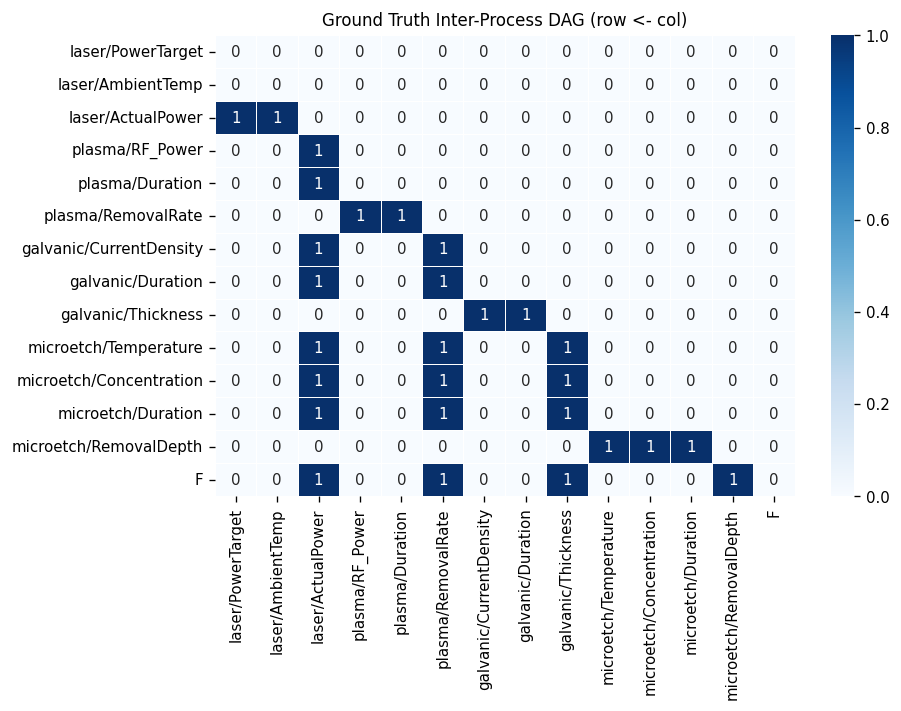

In [4]:
# Visualise the ground-truth adjacency matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    gt_dag, annot=True, fmt='d', cmap='Blues',
    xticklabels=gt_dag.columns, yticklabels=gt_dag.index,
    linewidths=0.5, ax=ax,
)
ax.set_title('Ground Truth Inter-Process DAG (row <- col)')
plt.tight_layout()
plt.show()

### 1b. Attention-based Discovery (requires trained CausaliT checkpoint)

Uncomment and adapt the cell below once a trained checkpoint is available.

In [5]:
# from causaliT.causal_discovery.attention_discovery import (
#     AttentionGraphExtractor, load_vars_maps,
# )
#
# # Load model and variable maps
# # model = ...  # Load your trained ProT / CausaliT checkpoint
# # iv_map, tv_map = load_vars_maps('path/to/generated_data/')
#
# # extractor = AttentionGraphExtractor(model, iv_map, tv_map)
# # extractor.register_hooks()
#
# # attn_matrices = extractor.collect_attention(dataloader, max_batches=50)
# # var_attn = extractor.attention_to_variable_graph(attn_matrices)
# # est_adj = AttentionGraphExtractor.threshold_to_adjacency(var_attn, threshold=0.1)
#
# # fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
# # for ax, (data, title, cmap) in zip(axes, [
# #     (gt_dag, 'Ground Truth', 'Blues'),
# #     (var_attn, 'Attention Weights', 'Reds'),
# #     (est_adj, 'Estimated DAG', 'Greens'),
# # ]):
# #     sns.heatmap(data, annot=True, fmt='.2f', cmap=cmap, ax=ax)
# #     ax.set_title(title)
# # plt.tight_layout()
# # plt.show()
print('Attention-based discovery section ready (requires trained checkpoint).')

Attention-based discovery section ready (requires trained checkpoint).


---
## 2. Causal Discovery Validation

In [6]:
from causaliT.causal_discovery.discovery_validation import DiscoveryValidator

validator = DiscoveryValidator(datasets, PROCESS_ORDER)
print(f'Ground truth shape: {validator.ground_truth.shape}')
print(f'Observable vars: {validator.obs_vars}')

# Generate i.i.d. data for classical baselines
iid_data = validator.generate_iid_data(n_samples=5000, seed=42)
print(f'\nGenerated i.i.d. data: {iid_data.shape}')
iid_data.describe()

Ground truth shape: (13, 13)
Observable vars: ['laser/PowerTarget', 'laser/AmbientTemp', 'laser/ActualPower', 'plasma/RF_Power', 'plasma/Duration', 'plasma/RemovalRate', 'galvanic/CurrentDensity', 'galvanic/Duration', 'galvanic/Thickness', 'microetch/Temperature', 'microetch/Concentration', 'microetch/Duration', 'microetch/RemovalDepth']

Generated i.i.d. data: (5000, 13)


,laser/PowerTarget,laser/AmbientTemp,laser/ActualPower,plasma/RF_Power,plasma/Duration,plasma/RemovalRate,galvanic/CurrentDensity,galvanic/Duration,galvanic/Thickness,microetch/Temperature,microetch/Concentration,microetch/Duration,microetch/RemovalDepth
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.546051,24.972617,0.446478,248.683709,34.931542,3.795278,2.982449,2095.892496,21.863749,307.868371,1.746577,105.242248,9.024018
std,0.259674,5.758708,0.273288,86.558117,14.396770,2.439424,1.154108,863.806212,12.986678,8.655812,0.719839,42.955549,6.678093
min,0.100467,15.006288,-0.112456,100.155623,10.015721,0.452395,1.002075,600.943259,2.354521,293.015562,0.500786,30.001975,-3.506748
25%,0.319967,19.972252,0.218736,173.322440,22.430631,2.017371,1.977633,1345.837837,11.405049,300.332244,1.121532,67.478986,4.285145
50%,0.542785,25.098870,0.433973,247.594870,35.247174,3.127374,2.967932,2114.830431,18.934929,307.759487,1.762359,105.774907,7.243584
75%,0.773795,29.846341,0.654325,324.598363,47.115853,4.995529,3.994645,2826.951206,30.264922,315.459836,2.355793,142.163573,11.968544
max,0.999789,34.999540,1.346520,399.929601,59.998851,12.894807,4.999061,3599.931061,70.136229,322.992960,2.999943,179.992089,50.032488


In [7]:
# Run classical baselines (GES, PC) if causal-learn is installed
try:
    classical_results = validator.validate_classical_baselines(
        iid_data, run_ges=True, run_pc=True, pc_alpha=0.05
    )
    for algo, res in classical_results.items():
        if 'error' not in res:
            print(f'\n{algo} results:')
            for k, v in res.items():
                if k != 'adjacency':
                    print(f'  {k}: {v}')
        else:
            print(f'{algo}: {res["error"]}')
except Exception as e:
    print(f'Classical baselines skipped: {e}')

Classical baselines skipped: Singular matrix


C:\Users\matte\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\causallearn\score\LocalScoreFunction.py:73: RuntimeWarning: divide by zero encountered in log
  H = np.log(cov[i, i] - yX @ np.linalg.inv(XX) @ yX.T)
C:\Users\matte\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\causallearn\utils\GESUtils.py:253: RuntimeWarning: invalid value encountered in subtract
  ch_score = score1 - score2
C:\Users\matte\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\causallearn\score\LocalScoreFunction.py:73: RuntimeWarning: invalid value encountered in log
  H = np.log(cov[i, i] - yX @ np.linalg.inv(XX) @ yX.T)


---
## 3. Interventional Validation

In [8]:
from causaliT.causal_discovery.interventional_analysis import InterventionalAnalyzer

interventional = InterventionalAnalyzer(datasets, PROCESS_ORDER)

# Example: do(PowerTarget = 0.8)
dist_cmp = interventional.compare_distributions(
    var='PowerTarget', value=0.8, n_samples=5000, seed=42
)
print('Distribution comparison for do(PowerTarget=0.8):')
dist_cmp[['mean_shift', 'ks_statistic', 'ks_pvalue']]

Distribution comparison for do(PowerTarget=0.8):


,mean_shift,ks_statistic,ks_pvalue
variable,,,
laser/PowerTarget,0.253949,0.7808,0.000000
laser/AmbientTemp,0.092835,0.0140,0.711289
laser/ActualPower,0.252342,0.5574,0.000000
plasma/RF_Power,0.972818,0.0154,0.593677
plasma/Duration,0.232087,0.0140,0.711289
plasma/RemovalRate,0.045219,0.0192,0.315388
galvanic/CurrentDensity,0.012971,0.0154,0.593677
galvanic/Duration,13.925201,0.0140,0.711289
galvanic/Thickness,0.117256,0.0154,0.593677


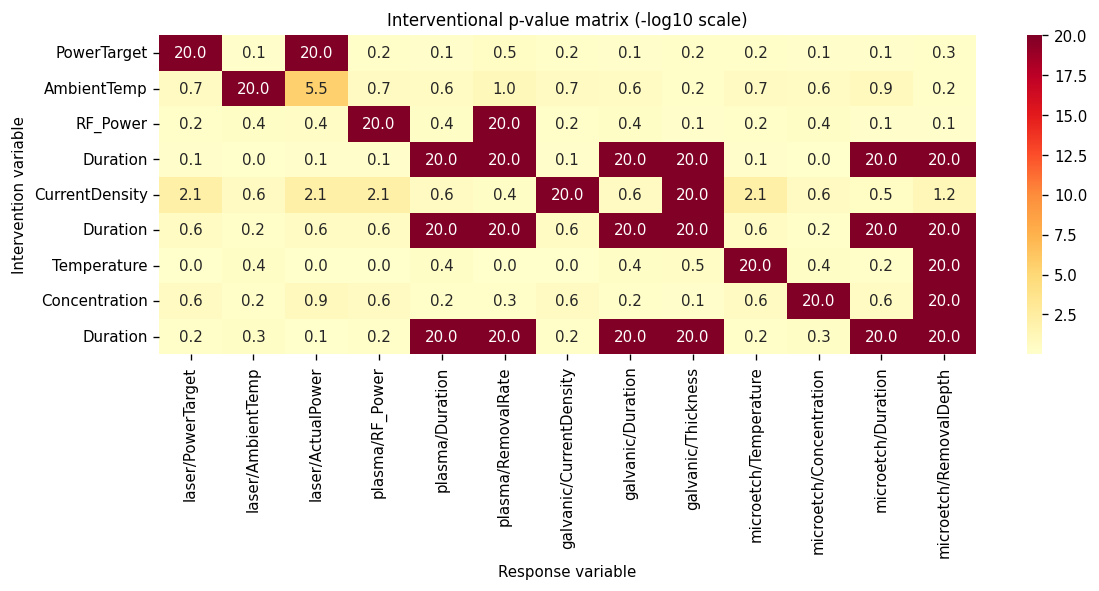


Significant effects (p < 0.05):


,laser/PowerTarget,laser/AmbientTemp,laser/ActualPower,plasma/RF_Power,plasma/Duration,plasma/RemovalRate,galvanic/CurrentDensity,galvanic/Duration,galvanic/Thickness,microetch/Temperature,microetch/Concentration,microetch/Duration,microetch/RemovalDepth
PowerTarget,True,False,True,False,False,False,False,False,False,False,False,False,False
AmbientTemp,False,True,True,False,False,False,False,False,False,False,False,False,False
RF_Power,False,False,False,True,False,True,False,False,False,False,False,False,False
Duration,False,False,False,False,True,True,False,True,True,False,False,True,True
CurrentDensity,True,False,True,True,False,False,True,False,True,True,False,False,False
Duration,False,False,False,False,True,True,False,True,True,False,False,True,True
Temperature,False,False,False,False,False,False,False,False,False,True,False,False,True
Concentration,False,False,False,False,False,False,False,False,False,False,True,False,True
Duration,False,False,False,False,True,True,False,True,True,False,False,True,True


In [9]:
# P-value matrix (Appendix V style)
pval_matrix, sig_matrix = interventional.compute_pvalue_matrix(
    n_samples=5000, seed=42, significance=0.05
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    -np.log10(pval_matrix + 1e-20),
    cmap='YlOrRd', ax=ax, annot=True, fmt='.1f',
    xticklabels=pval_matrix.columns,
    yticklabels=pval_matrix.index,
)
ax.set_title('Interventional p-value matrix (-log10 scale)')
ax.set_ylabel('Intervention variable')
ax.set_xlabel('Response variable')
plt.tight_layout()
plt.show()

print('\nSignificant effects (p < 0.05):')
sig_matrix

---
## 4. Out-of-Distribution Analysis

In [10]:
from causaliT.causal_discovery.ood_analysis import (
    OODAnalyzer, DEFAULT_SHIFTS,
)

ood = OODAnalyzer(datasets, PROCESS_ORDER)

# Run distributional comparison for all default shifts
ood_results = ood.run_full_ood_analysis(
    shifts=DEFAULT_SHIFTS, n_samples=5000, seed=42
)

for desc, df in ood_results.items():
    print(f'\n--- {desc} ---')
    print(df[['id_mean', 'ood_mean', 'mean_shift', 'ks_pvalue']].to_string())


--- Laser: AmbientTemp shift to higher range ---
                             id_mean     ood_mean  mean_shift     ks_pvalue
variable                                                                   
laser/PowerTarget           0.546051     0.554946    0.008894  5.512541e-02
laser/AmbientTemp          19.986308    29.987260   10.000952  0.000000e+00
laser/ActualPower           0.472772     0.427179   -0.045593  7.858993e-09
plasma/RF_Power           248.683709   251.648500    2.964791  5.512541e-02
plasma/Duration            34.931542    34.936302    0.004760  9.228577e-01
plasma/RemovalRate          3.795278     3.763531   -0.031747  2.295785e-01
galvanic/CurrentDensity     2.982449     3.021980    0.039531  5.512541e-02
galvanic/Duration        2095.892496  2096.178115    0.285619  9.228577e-01
galvanic/Thickness         21.863749    22.010787    0.147038  3.399454e-01
microetch/Temperature     307.868371   308.164850    0.296479  5.512541e-02
microetch/Concentration     1.746577  

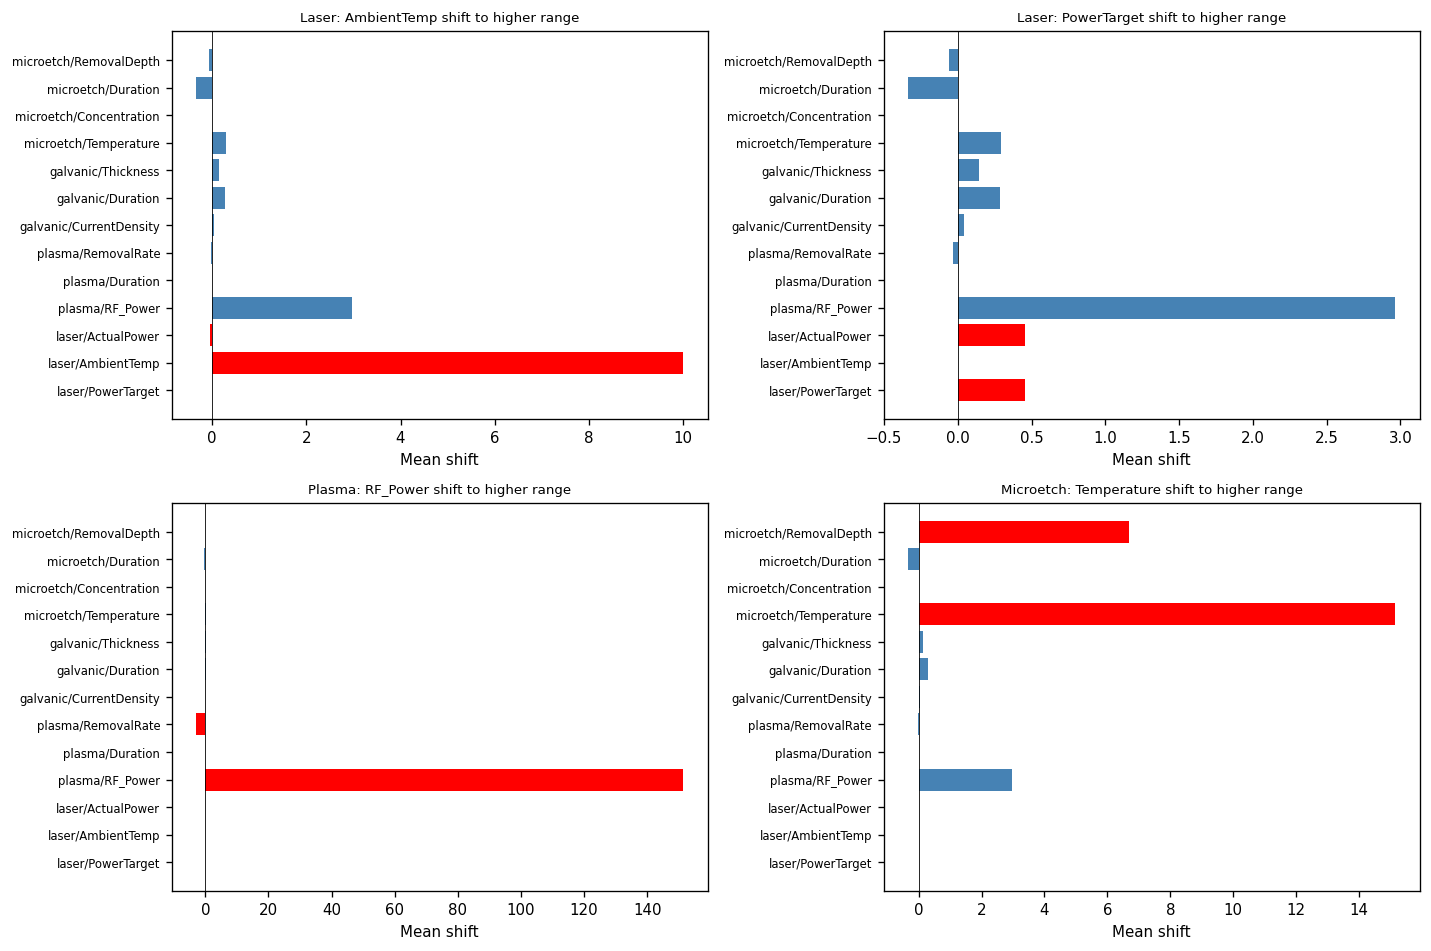

In [11]:
# Visualise the shift magnitudes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (desc, df) in zip(axes.flat, ood_results.items()):
    shifted = df['ks_pvalue'] < 0.05
    colors = ['red' if s else 'steelblue' for s in shifted]
    ax.barh(range(len(df)), df['mean_shift'].values, color=colors)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df.index, fontsize=7)
    ax.set_title(desc, fontsize=8)
    ax.set_xlabel('Mean shift')
    ax.axvline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 5. Symbolic Regression

In [12]:
from causaliT.causal_discovery.symbolic_analysis import SymbolicAnalyzer

symbolic = SymbolicAnalyzer(datasets, PROCESS_ORDER)

# Run polynomial baseline for all processes
sym_results = symbolic.run_full_analysis(
    n_samples=10000, seed=42, use_pysr=False, max_poly_degree=4
)

display_cols = [c for c in sym_results.columns if c != 'ground_truth_expr']
sym_results[display_cols]

,process,output_var,input_vars,poly_degree,poly_r2_train,poly_r2_test,poly_expression
0,laser,ActualPower,"PowerTarget, AmbientTemp",1,1.0,1.0,0
1,plasma,RemovalRate,"RF_Power, Duration",1,1.0,1.0,0
2,galvanic,Thickness,"CurrentDensity, Duration",2,1.0,1.0,0.003492*CurrentDensity Duration
3,microetch,RemovalDepth,"Temperature, Concentration, Duration",1,1.0,1.0,0


In [13]:
# Show ground truth vs discovered expressions
for _, row in sym_results.iterrows():
    proc = row['process']
    out_var = row['output_var']
    gt = row.get('ground_truth_expr', 'N/A')
    poly = row.get('poly_expression', 'N/A')
    r2 = row.get('poly_r2_test', 'N/A')
    print(f'\n{proc} / {out_var}:')
    print(f'  Ground truth : {gt}')
    print(f'  Polynomial   : {poly}')
    print(f'  R^2 (test)   : {r2}')


laser / ActualPower:
  Ground truth : NoiseDrift + NoiseMeas + NoiseShot + Pclean*Zln
  Polynomial   : 0
  R^2 (test)   : 1.0

plasma / RemovalRate:
  Ground truth : Jump + NoiseAdd + Rclean*Zln
  Polynomial   : 0
  R^2 (test)   : 1.0

galvanic / Thickness:
  Ground truth : NoiseMeas + Ripple + tCu_ideal*(SpatialVar + 1)
  Polynomial   : 0.003492*CurrentDensity Duration
  R^2 (test)   : 1.0

microetch / RemovalDepth:
  Ground truth : NoiseStudentT + Rremoved*Zln
  Polynomial   : 0
  R^2 (test)   : 1.0


---
## 6. Generate PDF Report

Assembles all results into a publication-ready PDF.

In [14]:
from causaliT.causal_discovery.report_generator import CausalAnalysisReportGenerator

output_dir = REPO_ROOT / 'causaliT' / 'causal_discovery' / 'reports'
output_dir.mkdir(exist_ok=True)

report = CausalAnalysisReportGenerator(output_dir / 'causal_analysis_report.pdf')
report.add_title()

# Section 1: Ground Truth
report.add_ground_truth_section(gt_dag)

# Section 3: Interventional
intervention_results = interventional.run_all_interventions(
    intervention_specs=[('PowerTarget', 0.8), ('RF_Power', 300.0)],
    n_samples=5000,
)
report.add_interventional_section(intervention_results, pval_matrix)

# Section 4: OOD
report.add_ood_section(ood_results)

# Section 5: Symbolic
report.add_symbolic_section(sym_results)

# Build the PDF
report_path = report.generate()
print(f'Report saved to: {report_path}')

Causal Analysis Report generated: C:\AZIMUTH\AZIMUTH\causaliT\causal_discovery\reports\causal_analysis_report.pdf
Report saved to: C:\AZIMUTH\AZIMUTH\causaliT\causal_discovery\reports\causal_analysis_report.pdf


---
*End of Causal Analysis Notebook*